<a href="https://colab.research.google.com/github/faezesarlakifar/APAI-project-work/blob/main/cost_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Efective instructions cost analysis

1. **Two ESM-2 checkpoints** (35M + 150M): so cost curves can be compared across model size as well as sequence length.

2. **A longer sequence length** (up to 8192): the quadratic-vs-linear gap barely shows below 1024, so this range is where it actually becomes visible.

3. **An RMT wrapper** implementing the segment-recurrent inference algorithm from the theoretical cost-analysis note: fixed-size blocks + a small carried memory state, instead of full self-attention over the whole sequence.

## 1. Install dependencies

In [1]:
!pip install -q torch transformers fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 1.5 MB/s eta 0:00:00


## 2. Imports and setup

In [2]:
import warnings
import logging
from typing import Dict, List, Optional

import torch
import torch.nn as nn
import transformers
from transformers import AutoModel
from fvcore.nn import FlopCountAnalysis

import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForMaskedLM
from scipy.stats import spearmanr

import json
import os

warnings.filterwarnings("ignore")
logging.getLogger("fvcore").setLevel(logging.ERROR)
transformers.logging.set_verbosity_error()  # silences the per-checkpoint LOAD REPORT


## 3. RMT wrapper

Segment-recurrent (RMT-style) wrapper around a pretrained ESM-2 encoder.

Splits the input into fixed-size blocks and carries a small set of learned memory
tokens across blocks (prepended to each block's real token embeddings), instead of
running full self-attention over the whole sequence at once. Matches the
`RMT_Inference` pseudocode from the theoretical cost-analysis note: memory state
`Mem_t` is updated each block and carried to block `t+1`.

Uses `inputs_embeds`, which is documented public API on `EsmModel` (checked against
the actual `transformers` source rather than guessed), plus `model.embeddings.
word_embeddings` and `model.config.hidden_size` — both stable across versions, so
this doesn't reach into undocumented internals.

In [3]:
class RMTWrapper(nn.Module):
    def __init__(self, base_model: nn.Module, block_size: int = 128, num_memory_tokens: int = 8):
        super().__init__()
        self.base_model = base_model
        self.block_size = block_size
        self.num_memory_tokens = num_memory_tokens
        hidden_size = base_model.config.hidden_size
        # learned initial memory state; broadcast across batch at forward time
        self.memory_init = nn.Parameter(torch.randn(1, num_memory_tokens, hidden_size) * 0.02)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        word_embeddings = self.base_model.embeddings.word_embeddings
        device = input_ids.device

        memory = self.memory_init.expand(batch_size, -1, -1).to(device)
        segment_outputs = []

        for start in range(0, seq_len, self.block_size):
            end = min(start + self.block_size, seq_len)
            segment_ids = input_ids[:, start:end]
            segment_embeds = word_embeddings(segment_ids)             # [B, seg_len, d]
            combined = torch.cat([memory, segment_embeds], dim=1)     # [B, m+seg_len, d]

            out = self.base_model(inputs_embeds=combined).last_hidden_state

            memory = out[:, : self.num_memory_tokens, :]               # carried forward
            segment_outputs.append(out[:, self.num_memory_tokens :, :])

        return torch.cat(segment_outputs, dim=1)


## 4. Single measurement helper

One MACs + peak-memory measurement for a given model and input. Returns `None` on
OOM instead of crashing, so the sweep can log it and move on — expected at 8192 for
the full-sequence 150M variant, and that's actually the interesting data point:
exactly where RMT's constant-memory property should show up as the baseline falls
over.

In [4]:
def measure_once(model: nn.Module, input_ids: torch.Tensor) -> Optional[Dict[str, float]]:
    # Single MACs + peak-memory measurement. Returns None on OOM.
    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

        with torch.no_grad():
            _ = model(input_ids)
        peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

        macs = FlopCountAnalysis(model, input_ids).total()
        return {"macs": macs, "peak_mem_mb": peak_mem_mb}

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache()
            return None
        raise


## 5. Main sweep

Loops over both model checkpoints, and within each, over `full-sequence` (raw
`AutoModel`) vs. `RMT (b=128)` (the wrapper above), across the sequence-length
sweep. Each (variant, length) combo is measured `num_repeats` times and averaged.

Out Of Memory is caught and logged as `"OOM"` in the
results rather than crashing the cost analysis.

In [5]:
def run_extended_cost_sweep(
    model_configs: List[str] = None,
    block_size: int = 128,
    num_memory_tokens: int = 8,
    num_repeats: int = 3,
) -> List[Dict]:

    if model_configs is None:
        model_configs = ["facebook/esm2_t12_35M_UR50D", "facebook/esm2_t30_150M_UR50D"]

    sequences_sorted = sequence_lengths_table.sort_values("seq_length")
    all_results = []

    for model_name in model_configs:
        print()
        print("=" * 80)
        print(f"Loading {model_name}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        base_model = AutoModel.from_pretrained(model_name).cuda().eval()
        rmt_model = RMTWrapper(base_model, block_size=block_size,
                                num_memory_tokens=num_memory_tokens).cuda().eval()

        variants = {
            "full-sequence": base_model,
            f"RMT (b={block_size})": rmt_model,
        }

        print(f"{'Variant':<18} | {'DMS_id':<25} | {'Seq Len':<8} | {'Avg MACs':<14} | {'Avg Peak Mem (MB)':<18}")
        print("-" * 90)

        for variant_name, model in variants.items():
            for _, row in sequences_sorted.iterrows():
                dms_id = row["DMS_id"]
                seq_length = int(row["seq_length"])
                encoded = tokenizer(row["mutated_sequence"], add_special_tokens=False, return_tensors="pt")
                real_input = encoded["input_ids"].cuda()

                macs_runs, mem_runs = [], []
                oom = False
                for _ in range(num_repeats):
                    result = measure_once(model, real_input)
                    if result is None:
                        oom = True
                        break
                    macs_runs.append(result["macs"])
                    mem_runs.append(result["peak_mem_mb"])

                if oom:
                    print(f"{variant_name:<18} | {dms_id:<25} | {seq_length:<8} | {'OOM':<14} | {'OOM':<18}")
                    all_results.append({"model": model_name, "variant": variant_name,
                                         "DMS_id": dms_id, "seq_length": seq_length,
                                         "macs": None, "peak_mem_mb": None, "status": "OOM"})
                    continue

                avg_macs = sum(macs_runs) / num_repeats
                avg_mem = sum(mem_runs) / num_repeats
                print(f"{variant_name:<18} | {dms_id:<25} | {seq_length:<8} | {avg_macs:<14.0f} | {avg_mem:<18.2f}")
                all_results.append({"model": model_name, "variant": variant_name,
                                     "DMS_id": dms_id, "seq_length": seq_length,
                                     "macs": avg_macs, "peak_mem_mb": avg_mem, "status": "ok"})

        del base_model, rmt_model
        torch.cuda.empty_cache()

    return all_results


## 6. Save results + plot

Saves the raw sweep to CSV and plots MACs and peak memory vs. sequence length
(log-log), grouped by model + variant. This is the empirical curve to fit against
the theoretical O(n²) vs. O(n) shapes from the cost-analysis note, if you want to
take the ideal-vs-effective comparison further.

In [6]:
def save_and_plot(results: List[Dict], out_prefix: str = "cost_sweep_extended"):

    df = pd.DataFrame(results)
    df.to_csv(f"{out_prefix}.csv", index=False)
    print(f"\nSaved raw results to {out_prefix}.csv")

    ok = df[df["status"] == "ok"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for (model, variant), group in ok.groupby(["model", "variant"]):
        label = f"{model.split('/')[-1]} - {variant}"
        axes[0].plot(group["seq_length"], group["macs"], marker="o", label=label)
        axes[1].plot(group["seq_length"], group["peak_mem_mb"], marker="o", label=label)

    for ax, title, ylabel in zip(axes, ["MACs vs sequence length", "Peak memory vs sequence length"],
                                  ["MACs", "Peak memory (MB)"]):
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xlabel("Sequence length")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{out_prefix}.png", dpi=150)
    print(f"Saved plot to {out_prefix}.png")


### Using the actual protein sequences we have, at their real lengths

Rather than sweeping a fixed target-length list (64, 128, 256, ...) and
searching for a real sequence close enough to each one, the sweep now just
iterates over the real assays in `assay_df_all` directly, at whatever length
each one actually is. Every data point is a real, whole ProteinGym sequence
-- no matching, no tolerance, no fabricated target.

Trade-off worth knowing: `assay_df_all` has `n_per_bucket` assays per bucket
(2 by default) -- 6 sequences total, at whatever lengths those particular
proteins happen to be, not an even power-of-2 sweep. Raise `n_per_bucket`
below for a denser curve, at the cost of a slower accuracy comparison, which
scales with the same assay count.

In [7]:
def load_stratified_assay_subset(n_per_bucket: int = 2, random_state: int = 42) -> pd.DataFrame:
    # Short (<200 aa) / medium (200-500 aa) / long (>500 aa) stratification. Used both here (for cost-sweep input sequences)
    # and in the accuracy comparison further down, so both measure the same assays.

    print("Loading ProteinGym_v1 (DMS_substitutions)...")
    dataset = load_dataset("OATML-Markslab/ProteinGym_v1", data_dir="DMS_substitutions", split="train")
    df = dataset.to_pandas()
    df["seq_length"] = df["mutated_sequence"].apply(len)

    assay_lengths = df.groupby("DMS_id")["seq_length"].first().reset_index()
    short_assays = assay_lengths[assay_lengths["seq_length"] < 200]
    medium_assays = assay_lengths[(assay_lengths["seq_length"] >= 200) & (assay_lengths["seq_length"] <= 500)]
    long_assays = assay_lengths[assay_lengths["seq_length"] > 500]

    selected = pd.concat([
        short_assays.sample(n=min(n_per_bucket, len(short_assays)), random_state=random_state).assign(bucket="short"),
        medium_assays.sample(n=min(n_per_bucket, len(medium_assays)), random_state=random_state).assign(bucket="medium"),
        long_assays.sample(n=min(n_per_bucket, len(long_assays)), random_state=random_state).assign(bucket="long"),
    ])

    working_df = df[df["DMS_id"].isin(selected["DMS_id"])].merge(
        selected[["DMS_id", "bucket"]], on="DMS_id", how="left"
    )
    return working_df


assay_df_all = load_stratified_assay_subset(n_per_bucket=2)
print(f"Selected {assay_df_all['DMS_id'].nunique()} assays across short/medium/long buckets")

sequence_lengths_table = assay_df_all.drop_duplicates(subset="DMS_id")[["DMS_id", "mutated_sequence", "seq_length", "bucket"]]
assay_df_all[["DMS_id", "bucket", "seq_length"]].drop_duplicates()


Loading ProteinGym_v1 (DMS_substitutions)...


README.md:   0%|          | 0.00/4.07k [00:00<?, ?B/s]

DMS_substitutions/train-00000-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 16.1MB            

DMS_substitutions/train-00000-of-00005.p(…): downloading bytes:           |  0.00B            

DMS_substitutions/train-00001-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 24.1MB            

...

DMS_substitutions/train-00004-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 22.8MB            

DMS_substitutions/train-00004-of-00005.p(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Selected 6 assays across short/medium/long buckets


,DMS_id,bucket,seq_length
0,TRPC_SACS2_Chan_2017,medium,248
1519,A4_HUMAN_Seuma_2022,long,770
16330,A0A140D2T1_ZIKV_Sourisseau_2019,long,3423
25906,SQSTM_MOUSE_Tsuboyama_2023_2RRU,short,40
26613,SUMO1_HUMAN_Weile_2017,short,101
28313,SPG1_STRSG_Wu_2016,medium,448


## 7. Run it

### Resuming across sessions

Each sweep below can take a while, and a single Colab session may not get
through all six block sizes in one sitting. Every `save_and_plot(...)` call
writes its results to its own CSV (`cost_sweep_b128.csv`, `cost_sweep_b64.csv`,
etc.). If you already have those files from a previous session -- either still
present in this runtime's disk, or re-uploaded -- run the cell below instead
of re-running a sweep, and it'll reload `resultsN` from disk.

Only reload the ones you actually have; leave the rest to be computed
normally further down.


Loading facebook/esm2_t12_35M_UR50D...


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

Variant            | DMS_id                    | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
------------------------------------------------------------------------------------------
full-sequence      | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 5906458240     | 708.41            
full-sequence      | SUMO1_HUMAN_Weile_2017    | 101      | 14913182416    | 711.41            
full-sequence      | TRPC_SACS2_Chan_2017      | 248      | 36617911168    | 719.02            
full-sequence      | SPG1_STRSG_Wu_2016        | 448      | 66148154368    | 729.07            
full-sequence      | A4_HUMAN_Seuma_2022       | 770      | 113691845920   | 744.25            
full-sequence      | A0A140D2T1_ZIKV_Sourisseau_2019 | 3423     | OOM            | OOM               
RMT (b=128)        | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 7087258368     | 708.90            
RMT (b=128)        | SUMO1_HUMAN_Weile_2017    | 101      | 16093982544    | 712.79            
RMT (b=128)        | TRPC_S

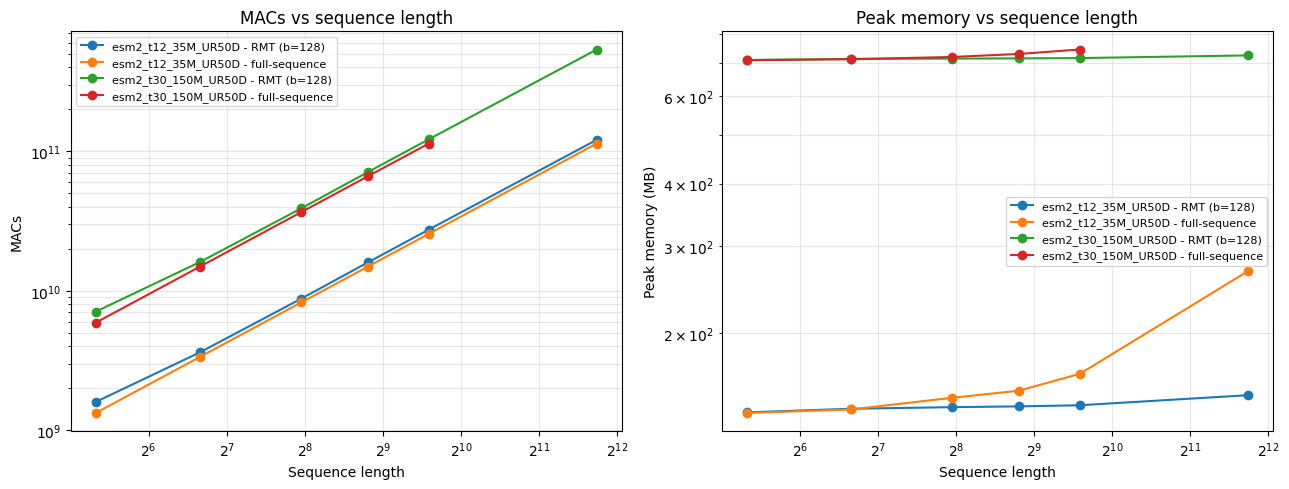

In [9]:
results1 = run_extended_cost_sweep(block_size=128)
save_and_plot(results1, out_prefix="cost_sweep_b128")


Loading facebook/esm2_t12_35M_UR50D...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Variant            | DMS_id                    | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
------------------------------------------------------------------------------------------
full-sequence      | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 1329734880     | 138.43            
full-sequence      | SUMO1_HUMAN_Weile_2017    | 101      | 3357229212     | 140.68            
full-sequence      | TRPC_SACS2_Chan_2017      | 248      | 8243158176     | 148.51            
full-sequence      | SPG1_STRSG_Wu_2016        | 448      | 14890680576    | 153.45            
full-sequence      | A4_HUMAN_Seuma_2022       | 770      | 25593191640    | 165.31            
full-sequence      | A0A140D2T1_ZIKV_Sourisseau_2019 | 3423     | 113772576276   | 266.71            
RMT (b=64)         | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 1595405376     | 138.80            
RMT (b=64)         | SUMO1_HUMAN_Weile_2017    | 101      | 3888800604     | 139.73            
RMT (b=64)         | TRPC_S

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

Variant            | DMS_id                    | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
------------------------------------------------------------------------------------------
full-sequence      | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 5906458240     | 708.34            
full-sequence      | SUMO1_HUMAN_Weile_2017    | 101      | 14913182416    | 711.33            
full-sequence      | TRPC_SACS2_Chan_2017      | 248      | 36617911168    | 718.94            
full-sequence      | SPG1_STRSG_Wu_2016        | 448      | 66148154368    | 728.99            
full-sequence      | A4_HUMAN_Seuma_2022       | 770      | 113691845920   | 744.17            
full-sequence      | A0A140D2T1_ZIKV_Sourisseau_2019 | 3423     | OOM            | OOM               
RMT (b=64)         | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 7087258368     | 708.83            
RMT (b=64)         | SUMO1_HUMAN_Weile_2017    | 101      | 17275192272    | 710.06            
RMT (b=64)         | TRPC_S

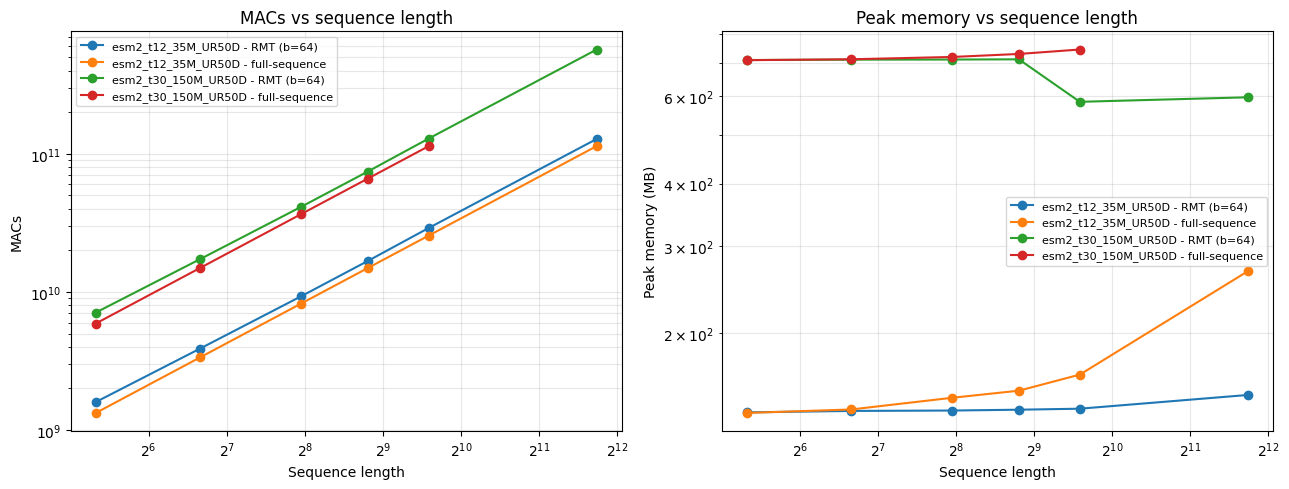

In [10]:
results2 = run_extended_cost_sweep(block_size=64)
save_and_plot(results2, out_prefix="cost_sweep_b64")

In [ ]:
results3 = run_extended_cost_sweep(block_size=32)
save_and_plot(results3, out_prefix="cost_sweep_b32")

#### Save

In [15]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/APAI_project/cost_sweep_results"
os.makedirs(save_dir, exist_ok=True)

for name, results in [("results1", results1), ("results2", results2), ("results3", results3)]:
    path = f"{save_dir}/{name}.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved {name} ({len(results)} rows) to {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved results1 (24 rows) to /content/drive/MyDrive/APAI_project/cost_sweep_results/results1.json
Saved results2 (24 rows) to /content/drive/MyDrive/APAI_project/cost_sweep_results/results2.json
Saved results3 (24 rows) to /content/drive/MyDrive/APAI_project/cost_sweep_results/results3.json


##### Load

In [8]:
def load_results_from_csv(out_prefix: str) -> List[Dict]:
    df = pd.read_csv(f"{out_prefix}.csv")
    df = df.where(pd.notnull(df), None)  # NaN -> None, matches the original dicts (e.g. macs=None on OOM/skipped)
    return df.to_dict("records")

In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_dir = "/content/drive/MyDrive/APAI_project/cost_sweep_results"

with open(f"{save_dir}/results1.json") as f:
    results1 = json.load(f)
with open(f"{save_dir}/results2.json") as f:
    results2 = json.load(f)

print(f"Loaded results1 ({len(results1)}), results2 ({len(results2)})")

Mounted at /content/drive
Loaded results1 (24), results2 (24)


In [ ]:
results4 = run_extended_cost_sweep(block_size=8)
save_and_plot(results4, out_prefix="cost_sweep_b8")


Loading facebook/esm2_t12_35M_UR50D...


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  136MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Variant            | DMS_id                    | Seq Len  | Avg MACs       | Avg Peak Mem (MB) 
------------------------------------------------------------------------------------------
full-sequence      | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 1329734880     | 138.43            
full-sequence      | SUMO1_HUMAN_Weile_2017    | 101      | 3357229212     | 140.68            
full-sequence      | TRPC_SACS2_Chan_2017      | 248      | 8243158176     | 148.51            
full-sequence      | SPG1_STRSG_Wu_2016        | 448      | 14890680576    | 153.45            
full-sequence      | A4_HUMAN_Seuma_2022       | 770      | 25593191640    | 165.91            
full-sequence      | A0A140D2T1_ZIKV_Sourisseau_2019 | 3423     | 113772576276   | 266.71            
RMT (b=8)          | SQSTM_MOUSE_Tsuboyama_2023_2RRU | 40       | 2659008960     | 137.68            
RMT (b=8)          | SUMO1_HUMAN_Weile_2017    | 101      | 6813710460     | 137.88            
RMT (b=8)          | TRPC_S

In [ ]:
for name, results in [("results4", results4)]:
    path = f"{save_dir}/{name}.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved {name} ({len(results)} rows) to {path}")

#### A little bit focusing on biological aspects:

The most reasonable block size for chopping protein sequences depends on your specific application, but a length of 3 to 7 amino acids is ideal for sequence pattern matching (k-mers), while 50 to 150 amino acids is ideal for structural or functional domain analysis.
Choosing the right size requires balancing biological meaning with computational complexity.
#### Summary of Block Sizes

| Application | Block Size (Length) | Why This Size? |
|---|---|---|
| Motifs & K-mers | 3 – 7 amino acids | Captures highly conserved functional sites and local patterns without losing statistical significance. |
| Epitope Prediction | 8 – 15 amino acids | Matches the exact physical length of peptides that bind to MHC I and MHC II immune receptors. |
| Structural Domains | 50 – 150 amino acids | Captures independently folding, evolutionary stable structural and functional units of proteins. |

------------------------------
#### 1. Short Blocks: 3 to 7 Amino Acids (Motifs & K-mers)

* Mathematical space: The protein alphabet has 20 letters. A block size of k creates $20^k$ possible combinations.
* Why 3 is the lower limit: A size of 3 (20³ = 8,000 combinations) or 4 (20⁴ = 160,000 combinations) is excellent for finding short, local patterns like phosphorylation sites.
* The random match problem: If your blocks are too short (e.g., 2 amino acids), they will appear everywhere purely by random chance (20² = 400 combinations), rendering them biologically meaningless.
* The sparsity problem: If you choose a size higher than 7 (20⁷ = 1.28 × 10⁹ combinations), the sequence space becomes so vast that you will rarely find exact matches between different proteins.

#### 2. Medium Blocks: 8 to 15 Amino Acids (Immunology & Peptides)

* Biological binding: This range is the precise size used by the immune system to recognize foreign proteins.
* MHC complexes: T-cells recognize linear peptide fragments of 8–11 amino acids (MHC Class I) or 13–17 amino acids (MHC Class II).
* Machine learning: If you are building models for vaccine design or immunotherapy, slicing sequences into overlapping 9-mers (sliding window of 9, step of 1) is the standard industry benchmark.

#### 3. Long Blocks: 50 to 150 Amino Acids (Structural Domains)

* Autonomous folding: Proteins are naturally modular. A domain is a self-stabilizing segment that folds independently of the rest of the protein chain.
* Evolutionary conservation: Nature shuffles these larger blocks around to create new proteins. Slicing at this scale allows you to identify functional building blocks (like kinase domains or zinc fingers).

In [ ]:
results5 = run_extended_cost_sweep(block_size=3)
save_and_plot(results5, out_prefix="cost_sweep_b3")

In [ ]:
for name, results in [("results5", results5)]:
    path = f"{save_dir}/{name}.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved {name} ({len(results)} rows) to {path}")

## Comparing block sizes

`results1` through `results6` above each swept one block size (128, 64, 32, 16,
8, 3) independently, each re-measuring the full-sequence baseline too. This
section combines them into one comparison: MACs and peak memory per block size
at every sequence length, plus a slice at a fixed long sequence length to see
the actual cost-vs-block-size trade-off directly (rather than reading it off
six separate plots).

In [ ]:
block_size_variants_map = {
    128: results1,
    64: results2,
    32: results3,
    8: results4,
    3: results5,
}

combined_rows = []
seen_full_sequence = set()

for block_size, results in block_size_variants_map.items():
    for r in results:
        row = dict(r)
        if r["variant"] == "full-sequence":
            # full-sequence baseline is identical across every block-size sweep;
            # keep only one copy per (model, seq_length) instead of 6 duplicates
            key = (r["model"], r["seq_length"])
            if key in seen_full_sequence:
                continue
            seen_full_sequence.add(key)
            row["block_size"] = None
        else:
            row["block_size"] = block_size
        combined_rows.append(row)

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv("block_size_comparison.csv", index=False)
print(f"Combined {len(combined_df)} rows across {len(block_size_variants_map)} block sizes")
combined_df.head()


In [ ]:
def plot_block_size_comparison(df, model_name, seq_length_for_slice=2048):
    model_df = df[df["model"] == model_name]
    ok = model_df[model_df["status"] == "ok"]

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    # 1. per-token MACs vs seq length, one line per block size.
    # Per-token normalizes out the dominant linear term so differences between
    # block sizes are actually visible instead of being buried in magnitude.
    for block_size, group in ok.groupby("block_size", dropna=False):
        group = group.sort_values("seq_length")
        macs_per_token = group["macs"] / group["seq_length"]
        label = "full-sequence" if pd.isna(block_size) else f"RMT b={int(block_size)}"
        axes[0].plot(group["seq_length"], macs_per_token, marker="o", label=label)
    axes[0].set_xscale("log", base=2)
    axes[0].set_xlabel("Sequence length")
    axes[0].set_ylabel("MACs per token")
    axes[0].set_title(f"{model_name}\nPer-token MACs by block size")
    axes[0].legend(fontsize=7)
    axes[0].grid(True, alpha=0.3)

    # 2. peak memory vs seq length, one line per block size.
    for block_size, group in ok.groupby("block_size", dropna=False):
        group = group.sort_values("seq_length")
        label = "full-sequence" if pd.isna(block_size) else f"RMT b={int(block_size)}"
        axes[1].plot(group["seq_length"], group["peak_mem_mb"], marker="o", label=label)
    axes[1].set_xscale("log", base=2)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Sequence length")
    axes[1].set_ylabel("Peak memory (MB)")
    axes[1].set_title(f"{model_name}\nPeak memory by block size")
    axes[1].legend(fontsize=7)
    axes[1].grid(True, which="both", alpha=0.3)

    # 3. the actual sweet-spot view, cost vs block size at one fixed,
    # long sequence length.
    slice_df = ok[ok["seq_length"] == seq_length_for_slice].dropna(subset=["block_size"])
    slice_df = slice_df.sort_values("block_size")
    if not slice_df.empty:
        ax3b = axes[2].twinx()
        axes[2].plot(slice_df["block_size"], slice_df["macs"], marker="o", color="tab:blue", label="MACs")
        ax3b.plot(slice_df["block_size"], slice_df["peak_mem_mb"], marker="s", color="tab:red", label="Peak mem (MB)")
        axes[2].set_xscale("log", base=2)
        axes[2].set_xlabel("Block size (b)")
        axes[2].set_ylabel("MACs", color="tab:blue")
        ax3b.set_ylabel("Peak memory (MB)", color="tab:red")
        axes[2].set_title(f"{model_name}\nCost vs block size at n={seq_length_for_slice}")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, f"No data at n={seq_length_for_slice}", ha="center", va="center")

    plt.tight_layout()
    safe_name = model_name.split("/")[-1]
    plt.savefig(f"block_size_comparison_{safe_name}.png", dpi=150)
    plt.show()


for model_name in combined_df["model"].unique():
    plot_block_size_comparison(combined_df, model_name)


## Accuracy Comparison

Same masked-marginal zero-shot scoring method as the Week 1 baseline script:
mask each mutated position, one forward pass per unique position, score =
`log P(mutant aa) - log P(wildtype aa)`, correlated (Spearman) against each
assay's experimental `DMS_score`. Extended here to run every variant --
full-sequence baseline and RMT at each of the block sizes swept above -- on
the same stratified short/medium/long assay subset, so cost and accuracy are
measured on directly comparable ground.

Two things this needs that the cost-sweep cells above didn't:
- **A model with an LM head.** `AutoModel` (used for MACs/memory) has no
  vocabulary projection, so accuracy uses `AutoModelForMaskedLM` instead, and
  a separate RMT wrapper (`RMTMaskedLM`) that carries the LM head through the
  segment loop.
- **The wildtype sequence per assay.** The dataset only stores the *mutant*
  sequence per row. For single mutants, the wildtype is recoverable by
  reverting the one substitution encoded in the `mutant` string -- done in
  `reconstruct_wildtype_sequence` below.

In [ ]:
def get_logits(model, input_ids):
    # Unifies AutoModelForMaskedLM (returns a MaskedLMOutput with .logits)
    # and RMTMaskedLM (returns a raw logits tensor directly).
    output = model(input_ids)
    if hasattr(output, "logits"):
        return output.logits
    return output

### RMT wrapper with the LM head carried through

Same segment-recurrent mechanism as `RMTWrapper` above, but built around
`EsmForMaskedLM` (`.esm` for the encoder, `.lm_head` for the vocabulary
projection) instead of the bare `AutoModel`, so it can produce the same kind
of logits the baseline uses for masked-marginal scoring.

In [ ]:
class RMTMaskedLM(nn.Module):
    def __init__(self, mlm_model: nn.Module, block_size: int = 128, num_memory_tokens: int = 8):
        super().__init__()
        self.mlm_model = mlm_model
        self.encoder = mlm_model.esm          # underlying EsmModel, no pooling head
        self.lm_head = mlm_model.lm_head
        self.block_size = block_size
        self.num_memory_tokens = num_memory_tokens
        hidden_size = mlm_model.config.hidden_size
        self.memory_init = nn.Parameter(torch.randn(1, num_memory_tokens, hidden_size) * 0.02)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        word_embeddings = self.encoder.embeddings.word_embeddings
        device = input_ids.device

        memory = self.memory_init.expand(batch_size, -1, -1).to(device)
        segment_hidden_states = []

        for start in range(0, seq_len, self.block_size):
            end = min(start + self.block_size, seq_len)
            segment_ids = input_ids[:, start:end]
            segment_embeds = word_embeddings(segment_ids)
            combined = torch.cat([memory, segment_embeds], dim=1)

            out = self.encoder(inputs_embeds=combined).last_hidden_state

            memory = out[:, : self.num_memory_tokens, :]
            segment_hidden_states.append(out[:, self.num_memory_tokens :, :])

        hidden_states = torch.cat(segment_hidden_states, dim=1)
        logits = self.lm_head(hidden_states)
        return logits


### Scoring functions

`reconstruct_wildtype_sequence` reverts the single substitution in `mutant`
to recover the wildtype. `masked_marginal_scores` and `evaluate_assay` mirror
the Week 1 baseline script, generalized to accept any model + `get_logits`
combination.

In [ ]:
def reconstruct_wildtype_sequence(dms_id: str, working_df: pd.DataFrame) -> str:

    # ProteinGym's DMS_substitutions rows store the mutant sequence per variant, not a separate wildtype column.
    # For single mutants, the wildtype is recoverable by reverting the one substitution encoded in `mutant` (e.g. "A123G" -> position 123 was "A" in the wildtype).

    assay_rows = working_df[working_df["DMS_id"] == dms_id]
    single = assay_rows[~assay_rows["mutant"].str.contains(":")]
    row = single.iloc[0]
    wt_aa, pos, mt_aa = row["mutant"][0], int(row["mutant"][1:-1]), row["mutant"][-1]
    seq = list(row["mutated_sequence"])
    assert seq[pos - 1] == mt_aa, f"Unexpected residue at position {pos} for {dms_id}"
    seq[pos - 1] = wt_aa
    return "".join(seq)


@torch.no_grad()
def masked_marginal_scores(model, tokenizer, wt_sequence, mutations, device="cuda"):
    positions = sorted({int(m[1:-1]) for m in mutations})
    pos_to_logits = {}

    encoded = tokenizer(wt_sequence, return_tensors="pt").to(device)
    input_ids = encoded["input_ids"]
    mask_id = tokenizer.mask_token_id

    for pos in positions:
        masked_ids = input_ids.clone()
        masked_ids[0, pos] = mask_id
        logits = get_logits(model, masked_ids)[0, pos]
        pos_to_logits[pos] = torch.log_softmax(logits, dim=-1)

    scores = {}
    for m in mutations:
        wt_aa, pos, mt_aa = m[0], int(m[1:-1]), m[-1]
        log_probs = pos_to_logits[pos]
        wt_id = tokenizer.convert_tokens_to_ids(wt_aa)
        mt_id = tokenizer.convert_tokens_to_ids(mt_aa)
        scores[m] = (log_probs[mt_id] - log_probs[wt_id]).item()

    return scores


def evaluate_assay(model, tokenizer, dms_id, working_df, device="cuda"):
    assay_rows = working_df[working_df["DMS_id"] == dms_id]
    single_mutant_df = assay_rows[~assay_rows["mutant"].str.contains(":")]
    if len(single_mutant_df) < 5:
        return None

    wt_sequence = reconstruct_wildtype_sequence(dms_id, working_df)
    scores = masked_marginal_scores(model, tokenizer, wt_sequence, single_mutant_df["mutant"].tolist(), device)
    predicted = [scores[m] for m in single_mutant_df["mutant"]]
    actual = single_mutant_df["DMS_score"].tolist()

    rho, _ = spearmanr(predicted, actual)
    return rho


### Stratified assay subset

Short (<200 aa) / medium (200-500 aa) / long (>500 aa) stratification. `n_per_bucket` controls how many assays get sampled per
bucket, kept small by default since accuracy evaluation costs one forward
pass per unique mutated position, times every variant, times every assay.

In [ ]:
def load_stratified_assay_subset(n_per_bucket: int = 2, random_state: int = 42) -> pd.DataFrame:
    print("Loading ProteinGym_v1 (DMS_substitutions)...")
    dataset = load_dataset("OATML-Markslab/ProteinGym_v1", data_dir="DMS_substitutions", split="train")
    df = dataset.to_pandas()
    df["seq_length"] = df["mutated_sequence"].apply(len)

    assay_lengths = df.groupby("DMS_id")["seq_length"].first().reset_index()
    short_assays = assay_lengths[assay_lengths["seq_length"] < 200]
    medium_assays = assay_lengths[(assay_lengths["seq_length"] >= 200) & (assay_lengths["seq_length"] <= 500)]
    long_assays = assay_lengths[assay_lengths["seq_length"] > 500]

    selected = pd.concat([
        short_assays.sample(n=min(n_per_bucket, len(short_assays)), random_state=random_state).assign(bucket="short"),
        medium_assays.sample(n=min(n_per_bucket, len(medium_assays)), random_state=random_state).assign(bucket="medium"),
        long_assays.sample(n=min(n_per_bucket, len(long_assays)), random_state=random_state).assign(bucket="long"),
    ])

    working_df = df[df["DMS_id"].isin(selected["DMS_id"])].merge(
        selected[["DMS_id", "bucket"]], on="DMS_id", how="left"
    )
    return working_df


assay_df_all = load_stratified_assay_subset(n_per_bucket=2)
print(f"Selected {assay_df_all['DMS_id'].nunique()} assays across short/medium/long buckets")
assay_df_all[["DMS_id", "bucket", "seq_length"]].drop_duplicates()


Loading ProteinGym_v1 (DMS_substitutions)...


README.md:   0%|          | 0.00/4.07k [00:00<?, ?B/s]

DMS_substitutions/train-00000-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 16.1MB            

DMS_substitutions/train-00000-of-00005.p(…): downloading bytes:           |  0.00B            

DMS_substitutions/train-00001-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 24.1MB            

...

DMS_substitutions/train-00004-of-00005.p(…): reconstructing file:   0%|          |  0.00B / 22.8MB            

DMS_substitutions/train-00004-of-00005.p(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Selected 6 assays across short/medium/long buckets


,DMS_id,bucket,seq_length
0,TRPC_SACS2_Chan_2017,medium,248
1519,A4_HUMAN_Seuma_2022,long,770
16330,A0A140D2T1_ZIKV_Sourisseau_2019,long,3423
25906,SQSTM_MOUSE_Tsuboyama_2023_2RRU,short,40
26613,SUMO1_HUMAN_Weile_2017,short,101
28313,SPG1_STRSG_Wu_2016,medium,448


### Running the comparison

In [ ]:
def run_accuracy_comparison(
    assay_df_all: pd.DataFrame,
    model_configs: List[str] = None,
    block_sizes: List[int] = None,
    num_memory_tokens: int = 8,
    device: str = "cuda",
) -> pd.DataFrame:
    if model_configs is None:
        model_configs = ["facebook/esm2_t12_35M_UR50D", "facebook/esm2_t30_150M_UR50D"]
    if block_sizes is None:
        block_sizes = [128, 64, 32, 16, 8, 3]

    dms_ids = assay_df_all[["DMS_id", "bucket"]].drop_duplicates()
    accuracy_rows = []

    for model_name in model_configs:
        print()
        print("=" * 80)
        print(f"Loading {model_name} for accuracy comparison...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        mlm_model = AutoModelForMaskedLM.from_pretrained(model_name).to(device).eval()

        variants = {"full-sequence": mlm_model}
        for b in block_sizes:
            variants[f"RMT (b={b})"] = RMTMaskedLM(
                mlm_model, block_size=b, num_memory_tokens=num_memory_tokens
            ).to(device).eval()

        for variant_name, model in variants.items():
            for _, row in dms_ids.iterrows():
                dms_id, bucket = row["DMS_id"], row["bucket"]
                rho = evaluate_assay(model, tokenizer, dms_id, assay_df_all, device)
                print(f"  {model_name.split('/')[-1]:<20} | {variant_name:<14} | {dms_id:<30} | rho={rho}")
                accuracy_rows.append({
                    "model": model_name, "variant": variant_name,
                    "DMS_id": dms_id, "bucket": bucket, "spearman_rho": rho,
                })

        del mlm_model
        torch.cuda.empty_cache()

    return pd.DataFrame(accuracy_rows)


accuracy_df = run_accuracy_comparison(assay_df_all)
accuracy_df.to_csv("accuracy_comparison.csv", index=False)
accuracy_df.head()



Loading facebook/esm2_t12_35M_UR50D for accuracy comparison...


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

  esm2_t12_35M_UR50D   | full-sequence  | TRPC_SACS2_Chan_2017           | rho=0.5393074030826911
  esm2_t12_35M_UR50D   | full-sequence  | A4_HUMAN_Seuma_2022            | rho=0.3951103972788827
  esm2_t12_35M_UR50D   | full-sequence  | A0A140D2T1_ZIKV_Sourisseau_2019 | rho=-0.08283656335285279
  esm2_t12_35M_UR50D   | full-sequence  | SQSTM_MOUSE_Tsuboyama_2023_2RRU | rho=0.4422601047804813
  esm2_t12_35M_UR50D   | full-sequence  | SUMO1_HUMAN_Weile_2017         | rho=0.49615027874119144
  esm2_t12_35M_UR50D   | full-sequence  | SPG1_STRSG_Wu_2016             | rho=0.36721804511278194
  esm2_t12_35M_UR50D   | RMT (b=128)    | TRPC_SACS2_Chan_2017           | rho=0.4154316496112243
  esm2_t12_35M_UR50D   | RMT (b=128)    | A4_HUMAN_Seuma_2022            | rho=0.42039341376754275
  esm2_t12_35M_UR50D   | RMT (b=128)    | A0A140D2T1_ZIKV_Sourisseau_2019 | rho=-0.08380545632613966
  esm2_t12_35M_UR50D   | RMT (b=128)    | SQSTM_MOUSE_Tsuboyama_2023_2RRU | rho=0.4449438286947861
  esm2_t1

In [ ]:
summary = accuracy_df.groupby(["model", "variant", "bucket"])["spearman_rho"].mean().reset_index()
summary_pivot = summary.pivot_table(index=["model", "variant"], columns="bucket", values="spearman_rho")
print(summary_pivot)

variant_order = ["full-sequence"] + [f"RMT (b={b})" for b in [128, 64, 32, 16, 8, 3]]
overall = accuracy_df.groupby(["model", "variant"])["spearman_rho"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for model_name, group in overall.groupby("model"):
    group = group.set_index("variant").reindex(variant_order)
    ax.plot(group.index, group["spearman_rho"], marker="o", label=model_name.split("/")[-1])

ax.set_xlabel("Variant")
ax.set_ylabel("Mean Spearman rho (zero-shot fitness)")
ax.set_title("Accuracy vs. variant (averaged across assays)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()


## Ablation Study to find effective vs ineffective instructions and model blocks

The RMT algorithm has two structural "instructions" worth isolating from each
other, since block-size alone (swept above) doesn't separate them:

1. **`num_memory_tokens` (m)** -- how much state gets carried between blocks.
   `m=0` removes the memory mechanism entirely: the sequence is just chopped
   into independent blocks with zero cross-block information flow.
2. **`carry_memory`** -- whether the memory state is actually the *previous*
   block's updated output (real recurrence), or reset to its initial value at
   the start of every block (no recurrence -- each block sees fresh, untrained
   memory tokens regardless of what came before).

Sweeping both together answers the actual question an ablation is for: is the
memory mechanism doing anything, and specifically is it the *recurrence* that
matters, or would non-recurrent local memory tokens do just as well? A knob is
"ineffective" here if changing it moves cost without moving accuracy (or vice
versa).

In [ ]:
class RMTMaskedLMAblation(nn.Module):

# Same as RMTMaskedLM, with two extra knobs for the ablation:
      # - num_memory_tokens: 0 disables the memory mechanism entirely.
      # - carry_memory: if False, memory resets to memory_init at the start of every block instead of carrying the previous block's updated state forward
      # isolates whether recurrence itself is doing anything.

    def __init__(self, mlm_model, block_size=128, num_memory_tokens=8, carry_memory=True):
        super().__init__()
        self.mlm_model = mlm_model
        self.encoder = mlm_model.esm
        self.lm_head = mlm_model.lm_head
        self.block_size = block_size
        self.num_memory_tokens = num_memory_tokens
        self.carry_memory = carry_memory
        hidden_size = mlm_model.config.hidden_size
        if num_memory_tokens > 0:
            self.memory_init = nn.Parameter(torch.randn(1, num_memory_tokens, hidden_size) * 0.02)
        else:
            self.memory_init = None

    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        word_embeddings = self.encoder.embeddings.word_embeddings
        device = input_ids.device

        if self.num_memory_tokens > 0:
            memory = self.memory_init.expand(batch_size, -1, -1).to(device)
        else:
            memory = None

        segment_hidden_states = []

        for start in range(0, seq_len, self.block_size):
            end = min(start + self.block_size, seq_len)
            segment_ids = input_ids[:, start:end]
            segment_embeds = word_embeddings(segment_ids)

            if memory is not None:
                combined = torch.cat([memory, segment_embeds], dim=1)
            else:
                combined = segment_embeds

            out = self.encoder(inputs_embeds=combined).last_hidden_state

            if self.num_memory_tokens > 0:
                new_memory = out[:, : self.num_memory_tokens, :]
                segment_hidden_states.append(out[:, self.num_memory_tokens :, :])
                if self.carry_memory:
                    memory = new_memory
                else:
                    memory = self.memory_init.expand(batch_size, -1, -1).to(device)
            else:
                segment_hidden_states.append(out)

        hidden_states = torch.cat(segment_hidden_states, dim=1)
        logits = self.lm_head(hidden_states)
        return logits


In [ ]:
def run_ablation_study(
    assay_df_all: pd.DataFrame,
    model_name: str = "facebook/esm2_t12_35M_UR50D",
    block_size: int = 32,
    memory_token_options: List[int] = None,
    device: str = "cuda",
    n_assays_for_accuracy: int = 4,
) -> pd.DataFrame:
    if memory_token_options is None:
        memory_token_options = [0, 2, 4, 8, 16]

    print()
    print("=" * 80)
    print(f"Loading {model_name} for ablation study...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    mlm_model = AutoModelForMaskedLM.from_pretrained(model_name).to(device).eval()

    dms_ids = assay_df_all[["DMS_id", "bucket"]].drop_duplicates().head(n_assays_for_accuracy)
    cost_row = sequence_lengths_table.sort_values("seq_length", ascending=False).iloc[0]
    real_input = tokenizer(cost_row["mutated_sequence"], add_special_tokens=False,
                            return_tensors="pt")["input_ids"].to(device)
    actual_cost_length = int(cost_row["seq_length"])
    print(f"Using real sequence {cost_row['DMS_id']} (length {actual_cost_length}) for the cost measurement")

    settings = []
    for num_mem in memory_token_options:
        carry_options = [True, False] if num_mem > 0 else [True]  # carry is meaningless with no memory
        for carry in carry_options:
            settings.append((num_mem, carry))

    rows = []
    for num_mem, carry in settings:
        label = f"m={num_mem}, carry={carry}"
        print()
        print("-" * 60)
        print(f"Setting: {label}")

        variant_model = RMTMaskedLMAblation(
            mlm_model, block_size=block_size, num_memory_tokens=num_mem, carry_memory=carry
        ).to(device).eval()

        cost_result = measure_once(variant_model, real_input)
        macs = cost_result["macs"] if cost_result else None
        peak_mem = cost_result["peak_mem_mb"] if cost_result else None

        rhos = []
        for _, row in dms_ids.iterrows():
            rho = evaluate_assay(variant_model, tokenizer, row["DMS_id"], assay_df_all, device)
            if rho is not None:
                rhos.append(rho)
        mean_rho = sum(rhos) / len(rhos) if rhos else None

        print(f"  MACs={macs}  peak_mem_mb={peak_mem}  mean_spearman_rho={mean_rho}")

        rows.append({
            "num_memory_tokens": num_mem,
            "carry_memory": carry,
            "setting": label,
            "macs": macs,
            "peak_mem_mb": peak_mem,
            "mean_spearman_rho": mean_rho,
        })

        del variant_model
        torch.cuda.empty_cache()

    del mlm_model
    torch.cuda.empty_cache()

    return pd.DataFrame(rows)


ablation_df = run_ablation_study(assay_df_all)
ablation_df.to_csv("ablation_study.csv", index=False)
ablation_df


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for carry, group in ablation_df.groupby("carry_memory"):
    group = group.sort_values("num_memory_tokens")
    label = "carry memory forward (real RMT)" if carry else "reset every block (no recurrence)"
    axes[0].plot(group["num_memory_tokens"], group["mean_spearman_rho"], marker="o", label=label)
    axes[1].plot(group["num_memory_tokens"], group["peak_mem_mb"], marker="o", label=label)

axes[0].set_xlabel("Number of memory tokens (m)")
axes[0].set_ylabel("Mean Spearman rho")
axes[0].set_title("Accuracy vs memory-token count and recurrence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Number of memory tokens (m)")
axes[1].set_ylabel("Peak memory (MB)")
axes[1].set_title("Cost vs memory-token count and recurrence")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150)
plt.show()
